# Explainable Environmental Sound Classification (ESC)

## 1. Project Introduction
Environmental Sound Classification (ESC) aims to recognize and classify everyday sounds, such as car horns, children playing, or sirens. While Deep Learning models, particularly Convolutional Neural Networks (CNNs), have shown excellent performance on ESC tasks, they are often treated as "black boxes." 

**Explainable AI (XAI)** techniques help bridge this gap by revealing *why* a model made a specific prediction. In this notebook, we not only train a CNN on the UrbanSound8K dataset but also employ interpretability methods (like Grad-CAM and SHAP) to highlight the specific time-frequency regions in the audio that drove the model's decisions.



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2
import shap

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)



D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Dataset Loading
The UrbanSound8K dataset contains 8,732 audio clips across 10 classes. We will load the metadata CSV and plot the class distribution.



Total number of samples: 8732
Classes: <StringArray>
[        'dog_bark', 'children_playing',         'car_horn',
  'air_conditioner',     'street_music',         'gun_shot',
            'siren',    'engine_idling',       'jackhammer',
         'drilling']
Length: 10, dtype: str


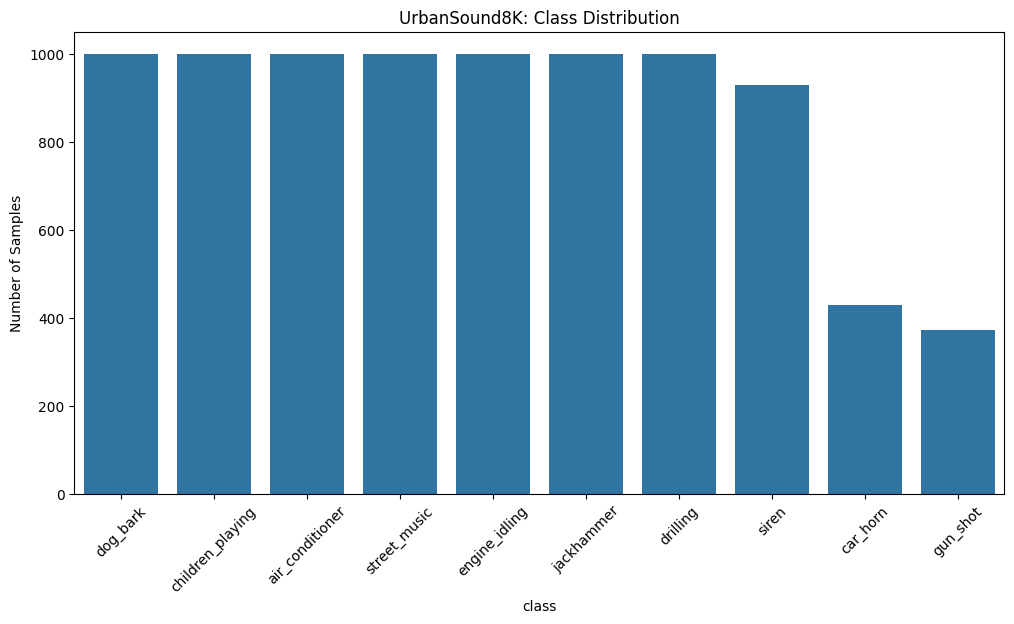

In [2]:
# Load Metadata
dataset_path = 'Dataset/UrbanSound8K.csv'
df = pd.read_csv(dataset_path)

# Show basic statistics
print(f"Total number of samples: {len(df)}")
print(f"Classes: {df['class'].unique()}")

# Plot Class Distribution
plt.figure(figsize=(12, 6))
sns.countplot(x='class', data=df, order=df['class'].value_counts().index)
plt.title('UrbanSound8K: Class Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Samples')
plt.show()



## 3. Audio Loading & 4. Audio Preprocessing
We define a function to load audio files using `librosa`. During loading, we will:
- **Resample**: Convert all audio to a uniform sample rate (e.g., 22,050 Hz).
- **Trim Silence**: Remove surrounding silence to focus on the active sound.
- **Normalize**: Scale the audio array to have values strictly bounded, preventing gradient issues.



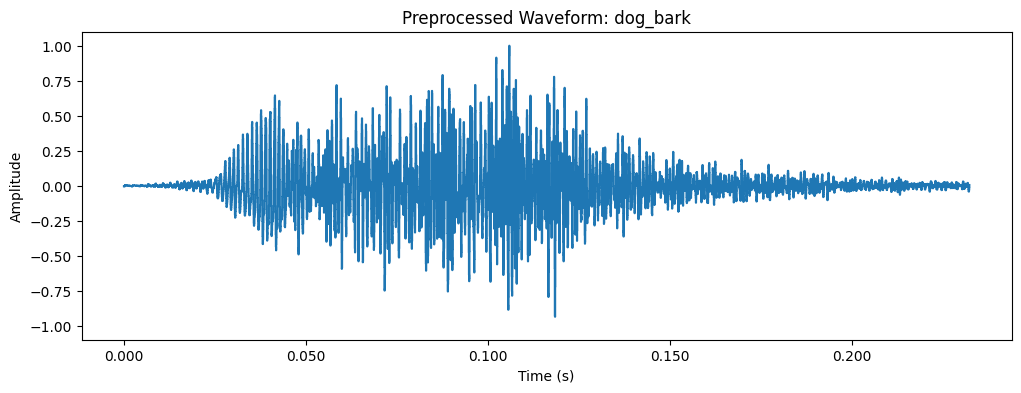

In [3]:
def preprocess_audio(file_path, target_sr=22050):
    """Loads, resamples, trims silence, and normalizes audio."""
    # Load and resample
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)
    
    # Trim silence (top_db=20 means sounds > 20dB below reference are trimmed)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalize
    max_val = np.max(np.abs(y_trimmed))
    if max_val > 0:
        y_normalized = y_trimmed / max_val
    else:
        y_normalized = y_trimmed
        
    return y_normalized, sr

# Demonstrate on a single audio file
sample_row = df.iloc[0]
sample_file = f"Dataset/fold{sample_row['fold']}/{sample_row['slice_file_name']}"

if os.path.exists(sample_file):
    y_norm, sr = preprocess_audio(sample_file)
    
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y_norm, sr=sr)
    plt.title(f"Preprocessed Waveform: {sample_row['class']}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.show()
    
    display(ipd.Audio(y_norm, rate=sr))
else:
    print(f"File not found: {sample_file}")



## 5. Feature Extraction
Because CNNs thrive on 2D images, we extract **Mel Spectrograms**, turning 1D audio into 2D time-frequency representations.
- `n_mels`: Number of Mel bands to generate (resolution of the frequency axis).
- `hop_length`: Number of audio frames between STFT columns (controls the time-axis resolution).
- `fmax`: Highest frequency captured.



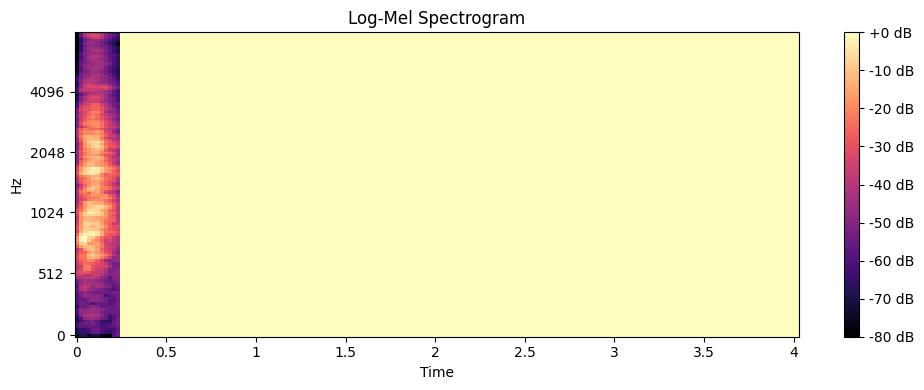

In [4]:
def extract_mel_spectrogram(y, sr, n_mels=128, hop_length=512, fmax=8000, max_pad_len=174):
    """Converts audio array into a padded Log-Mel Spectrogram."""
    # Calculate Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
    
    # Convert power to decibels (log scale)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # Padding / Truncating to ensure fixed size input for CNN
    if S_dB.shape[1] > max_pad_len:
        S_dB = S_dB[:, :max_pad_len]
    else:
        pad_width = max_pad_len - S_dB.shape[1]
        S_dB = np.pad(S_dB, pad_width=((0, 0), (0, pad_width)), mode='constant')
        
    return S_dB

if os.path.exists(sample_file):
    mel_spec = extract_mel_spectrogram(y_norm, sr)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec, sr=sr, hop_length=512, x_axis='time', y_axis='mel', fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title('Log-Mel Spectrogram')
    plt.tight_layout()
    plt.show()



## 6. Dataset Preparation
We iterate through the dataset to extract features. 
*(Note: Processing all 8,700 items takes time. For demonstration or rapid prototyping, you might process a subset. Here we show the complete logic, assuming you want to build the final arrays.)*



In [5]:
def prepare_dataset(df, base_path="Dataset/", max_samples=1000):
    """
    Iterates over the dataframe to load audio, extract spectrograms, and label them.
    max_samples limits the process for speed in this demonstration. Set to len(df) for full training.
    """
    features = []
    labels = []
    
    # Sample the dataframe to load a subset quickly for this notebook, 
    # or process everything if max_samples is larger than df size.
    df_subset = df.sample(n=min(max_samples, len(df)), random_state=42)
    
    for _, row in df_subset.iterrows():
        file_path = os.path.join(base_path, f"fold{row['fold']}", row['slice_file_name'])
        if os.path.exists(file_path):
            try:
                y, sr = preprocess_audio(file_path)
                mel = extract_mel_spectrogram(y, sr)
                features.append(mel)
                labels.append(row['classID'])
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                
    X = np.array(features)
    y = np.array(labels)
    
    # Reshape for CNN input: (samples, height, width, channels)
    # Output shape should be like (samples, 128, 174, 1)
    X = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
    y = to_categorical(y, num_classes=10)
    
    return X, y

print("Preparing Dataset Features... (this may take a moment)")
# Change max_samples to a higher number (e.g., len(df)) to use the full dataset
X, y = prepare_dataset(df, max_samples=1500) 

print(f"Feature shape: {X.shape}")
print(f"Labels shape: {y.shape}")



Preparing Dataset Features... (this may take a moment)


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(


Feature shape: (1500, 128, 174, 1)
Labels shape: (1500, 10)


## 6b. Dataset Splitting
It is critical to run this cell sequentially after dataset preparation and *before* training or explaining (SHAP). Failing to run this sequentially will cause a `NameError: name 'X_train' is not defined`.



In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")



X_train shape: (1200, 128, 174, 1)
X_test shape: (300, 128, 174, 1)
y_train shape: (1200, 10)
y_test shape: (300, 10)


## 7. CNN Model Architecture
We build a robust 2D Convolutional Neural Network.
- **Conv2D & MaxPooling2D**: To capture local spatial patterns (like frequency shifts and harmonic stacks).
- **BatchNormalization & Dropout**: To stabilize training and prevent overfitting.
- **Dense Layers**: To map extracted feature maps to specific sound classes.



In [7]:
def build_cnn_model(input_shape=(128, 174, 1), num_classes=10):
    # Re-written using Functional API to guarantee Grad-CAM compatibility
    inputs = Input(shape=input_shape)
    
    x = Conv2D(32, kernel_size=(3, 3), activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(64, kernel_size=(3, 3), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Conv2D(128, kernel_size=(3, 3), activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.25)(x)
    
    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  metrics=['accuracy'])
    return model

model = build_cnn_model(input_shape=(X_train.shape[1], X_train.shape[2], 1))
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 174, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 172, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 172, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 86, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63, 86, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 84, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 84, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 42, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 42, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 40, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 40, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 20, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 35840)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       9,175,296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,271,434 (35.37 MB)

 Trainable params: 9,270,986 (35.37 MB)

 Non-trainable params: 448 (1.75 KB)

## 8. Model Training
We train the CNN and monitor the loss and accuracy metrics over epochs.



Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 743ms/step - accuracy: 0.2633 - loss: 8.6115 - val_accuracy: 0.2000 - val_loss: 2.9879
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 735ms/step - accuracy: 0.2833 - loss: 2.4176 - val_accuracy: 0.1733 - val_loss: 5.2492
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 719ms/step - accuracy: 0.2892 - loss: 2.0010 - val_accuracy: 0.2167 - val_loss: 4.5471
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 723ms/step - accuracy: 0.3192 - loss: 1.8650 - val_accuracy: 0.2700 - val_loss: 2.4685
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 728ms/step - accuracy: 0.3650 - loss: 1.7568 - val_accuracy: 0.2967 - val_loss: 2.7628
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 732ms/step - accuracy: 0.3650 - loss: 1.6661 - val_accuracy: 0.3233 - val_loss: 6.2921
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 724ms/step - accuracy: 0.4017 - loss: 1.6279 - val_accuracy: 0.2700 - val_loss: 3.5792
Epoch 8/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 728ms/step - accuracy: 0.4217 - loss: 1.5481 - val_accu

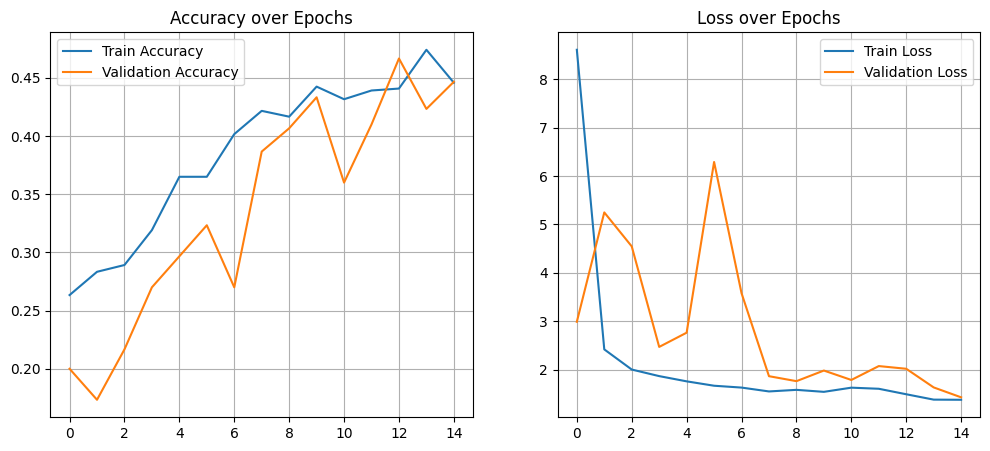

In [8]:
epochs = 15 # Set to 50 for better results if using the full dataset
batch_size = 32

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=epochs, 
    batch_size=batch_size, 
    verbose=1
)

# Plot training curves
plt.figure(figsize=(12, 5))

# Accuracy subset
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid()

# Loss subset
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid()

plt.show()



## 9. Model Evaluation
Evaluating the comprehensive performance using accuracy metrics and a Confusion Matrix.



Test Loss: 1.4264
Test Accuracy: 0.4467
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step


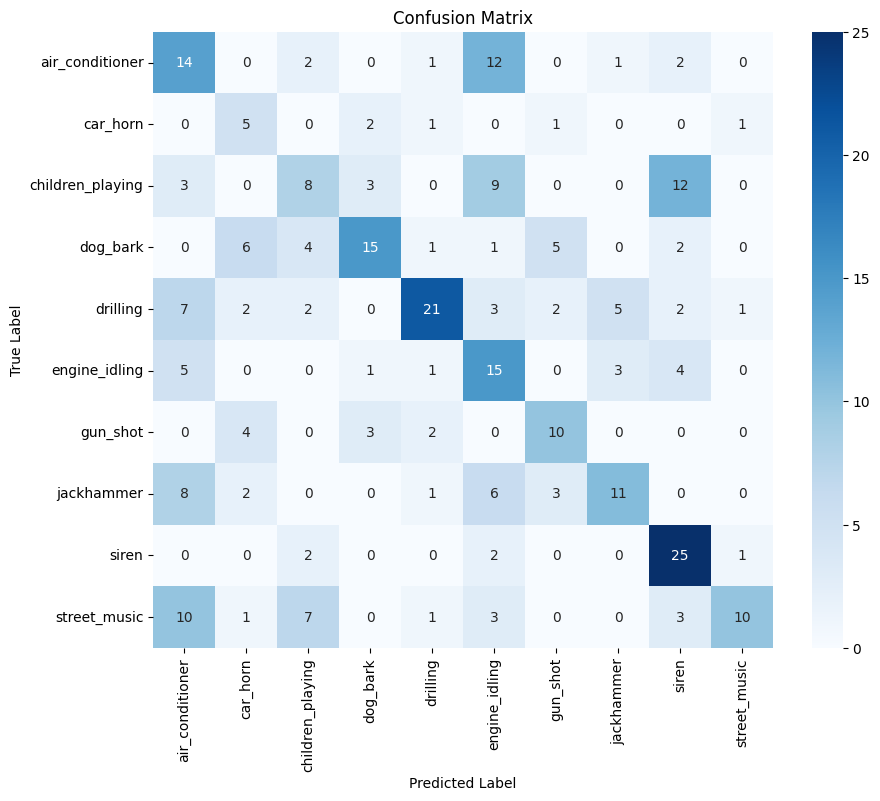


Classification Report:
                   precision    recall  f1-score   support

 air_conditioner       0.30      0.44      0.35        32
        car_horn       0.25      0.50      0.33        10
children_playing       0.32      0.23      0.27        35
        dog_bark       0.62      0.44      0.52        34
        drilling       0.72      0.47      0.57        45
   engine_idling       0.29      0.52      0.38        29
        gun_shot       0.48      0.53      0.50        19
      jackhammer       0.55      0.35      0.43        31
           siren       0.50      0.83      0.62        30
    street_music       0.77      0.29      0.42        35

        accuracy                           0.45       300
       macro avg       0.48      0.46      0.44       300
    weighted avg       0.51      0.45      0.45       300



In [9]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {score[0]:.4f}")
print(f"Test Accuracy: {score[1]:.4f}")

# Make predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Map class IDs to names
class_map = pd.Series(df['class'].values, index=df['classID'].values).to_dict()
class_labels = [class_map[i] for i in range(10)]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))



## 10. Grad-CAM Explainability
Grad-CAM overlays spatial attention heatmaps onto our Mel spectrogram, identifying exactly where the model looked before generating its prediction.



Model Layers:
 - input_layer
 - conv2d
 - batch_normalization
 - max_pooling2d
 - dropout
 - conv2d_1
 - batch_normalization_1
 - max_pooling2d_1
 - dropout_1
 - conv2d_2
 - batch_normalization_2
 - max_pooling2d_2
 - dropout_2
 - flatten
 - dense
 - dropout_3
 - dense_1
Using layer: conv2d_2 for Grad-CAM


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 174, 1))
  warnings.warn(msg)


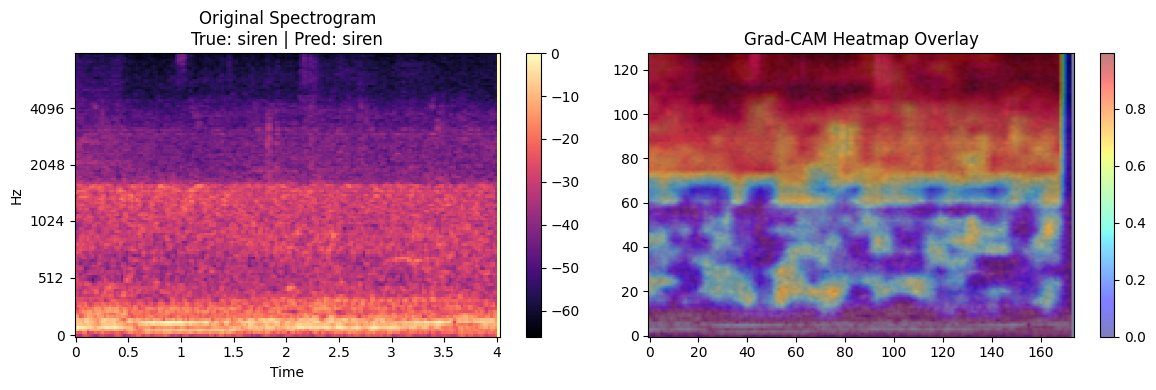

In [10]:
def get_last_conv_layer_name(model):
    """Automatically detect the last convolutional layer."""
    for layer in reversed(model.layers):
        if isinstance(layer, Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = get_last_conv_layer_name(model)
        
    print(f"Using layer: {last_conv_layer_name} for Grad-CAM")
    
    # 6. Ensure the model has been called before Grad-CAM is executed (dummy prediction)
    _ = model.predict(img_array, verbose=0)
    
    # 5. Build the gradient model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs, 
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        class_channel = preds[:, class_idx]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

# Select a test sample
# 7. Verify that the spectrogram input shape is correct (e.g., [1, 128, 174, 1])
sample_idx = 0
img_array = X_test[sample_idx:sample_idx+1]
true_class = class_map[np.argmax(y_test[sample_idx])]
pred_class = class_map[np.argmax(model.predict(img_array, verbose=0))]

print("Model Layers:")
for layer in model.layers:
    print(f" - {layer.name}")

heatmap = make_gradcam_heatmap(img_array, model)

# Resize heatmap to match image shape
heatmap_resized = cv2.resize(heatmap, (img_array.shape[2], img_array.shape[1]))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.specshow(img_array[0, :, :, 0], x_axis='time', y_axis='mel', fmax=8000)
plt.title(f'Original Spectrogram\nTrue: {true_class} | Pred: {pred_class}')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(img_array[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.imshow(heatmap_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
plt.title('Grad-CAM Heatmap Overlay')
plt.colorbar()
plt.tight_layout()
plt.show()



## 11. SHAP Explainability
SHAP values assign robust, game-theoretic pixel importance values. We sample background data and compute local SHAP estimations.



Data / model check:
  • model.input_shape  = (None, 128, 174, 1)
  • img_array.shape    = (1, 128, 174, 1)
  • X_train.shape      = (1200, 128, 174, 1)

Creating DeepExplainer...


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(30, 128, 174, 1))']
  warnings.warn(msg)


Explainer created successfully.
Computing SHAP values for one sample...


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(60, 128, 174, 1))']
  warnings.warn(msg)
D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 128, 174, 1))']
  warnings.warn(msg)



SHAP output inspection:
  • type(shap_values)     = <class 'numpy.ndarray'>
  • len(shap_values)      = —
  • shap_values.shape     = (1, 128, 174, 1, 10)

Predicted class: 8 → siren
→ SHAP returned single array (not list)


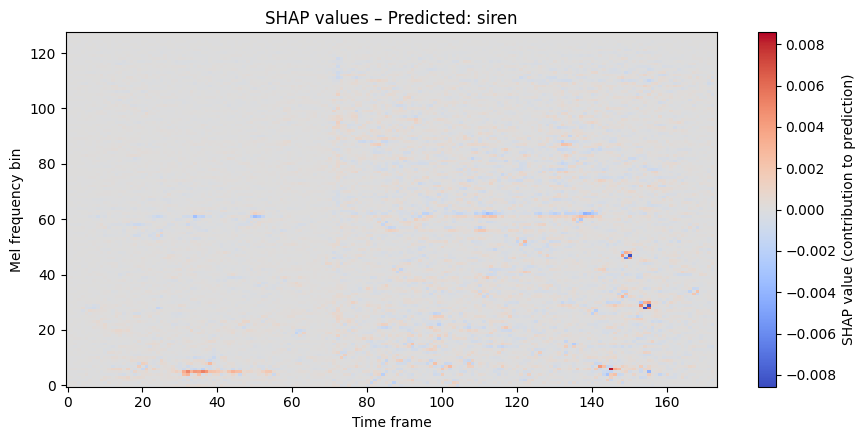

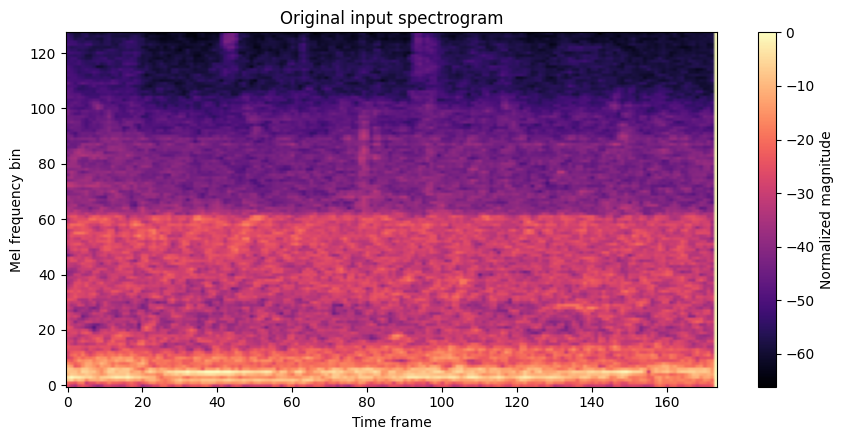

In [12]:
# ────────────────────────────────────────────────────────────────
#          SHAP visualization – robust version (2025 style)
# ────────────────────────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import shap
import tensorflow as tf

# ─── Safety / prerequisite checks ────────────────────────────────────────
if 'model' not in locals() or model is None:
    raise NameError("Model is not defined. Please run the model creation & training cells first.")

if 'X_train' not in locals() or 'X_test' not in locals():
    raise NameError("X_train / X_test not found. Run data loading & splitting cells first.")

if 'img_array' not in locals() or img_array is None:
    raise NameError("img_array is not defined. Run the Grad-CAM cell or define a sample first.")

print("Data / model check:")
print(f"  • model.input_shape  = {model.input_shape}")
print(f"  • img_array.shape    = {img_array.shape}")
print(f"  • X_train.shape      = {X_train.shape}")

# ─── Prepare small background set ────────────────────────────────────────
# 20–50 samples is usually a good trade-off between speed and stability
n_background = 30
if X_train.shape[0] < n_background:
    n_background = X_train.shape[0]
    print(f"Warning: using all {n_background} training samples as background (small dataset)")

rng = np.random.default_rng(42)  # reproducible
bg_idx = rng.choice(X_train.shape[0], size=n_background, replace=False)
background = X_train[bg_idx]

# ─── Create explainer ────────────────────────────────────────────────────
print("\nCreating DeepExplainer...")
try:
    explainer = shap.DeepExplainer(model, background)
    print("Explainer created successfully.")
except Exception as e:
    print("Error creating explainer:")
    print(e)
    print("\nCommon fixes:")
    print("  • Make sure model was compiled with categorical_crossentropy")
    print("  • Try smaller background (e.g. 10 samples)")
    print("  • Add activation='softmax' to last Dense layer if missing")
    raise

# ─── Compute SHAP values ─────────────────────────────────────────────────
print("Computing SHAP values for one sample...")
try:
    shap_values = explainer.shap_values(img_array)
except Exception as e:
    print("Error during shap_values computation:")
    print(e)
    raise

# ─── Inspect what we actually got from SHAP ──────────────────────────────
print("\nSHAP output inspection:")
print(f"  • type(shap_values)     = {type(shap_values)}")
print(f"  • len(shap_values)      = {len(shap_values) if isinstance(shap_values, (list,tuple)) else '—'}")

if isinstance(shap_values, (list, tuple)):
    print(f"  • shap_values[0].shape = {shap_values[0].shape}")
else:
    print(f"  • shap_values.shape     = {shap_values.shape}")

# ─── Select correct SHAP map ─────────────────────────────────────────────
pred_probs = model.predict(img_array, verbose=0)
predicted_class_idx = np.argmax(pred_probs[0])
pred_class_name = class_map[predicted_class_idx] if 'class_map' in globals() else f"class {predicted_class_idx}"

print(f"\nPredicted class: {predicted_class_idx} → {pred_class_name}")

# Most common patterns we see in practice
if isinstance(shap_values, (list, tuple)):
    if len(shap_values) == 1:
        # SHAP returned explanation only for the top class
        print("→ SHAP returned single-class explanation → using index 0")
        shap_for_pred = shap_values[0]
    elif len(shap_values) > predicted_class_idx:
        # Full multi-class explanations
        print(f"→ Using SHAP array for predicted class {predicted_class_idx}")
        shap_for_pred = shap_values[predicted_class_idx]
    else:
        raise ValueError(
            f"SHAP gave {len(shap_values)} arrays but predicted class is {predicted_class_idx}\n"
            "This usually means output layer mismatch or old SHAP version."
        )
else:
    # Rare – sometimes SHAP returns single array directly
    print("→ SHAP returned single array (not list)")
    shap_for_pred = shap_values

# Take first sample (batch size = 1), channel 0 (grayscale spectrogram)
shap_spec = shap_for_pred[0, ..., 0]   # shape should be ≈ (128, 174)

# ─── Visualization ───────────────────────────────────────────────────────
abs_max = np.max(np.abs(shap_spec))

plt.figure(figsize=(9, 4.5))
plt.imshow(
    shap_spec,
    aspect='auto',
    cmap='coolwarm',
    vmin=-abs_max,
    vmax=abs_max,
    origin='lower',
    interpolation='nearest'
)
plt.colorbar(label='SHAP value (contribution to prediction)')
plt.title(f'SHAP values – Predicted: {pred_class_name}')
plt.xlabel('Time frame')
plt.ylabel('Mel frequency bin')
plt.tight_layout()
plt.show()

# Optional: also show the original spectrogram beside it
if 'img_array' in globals() and img_array.shape[-1] == 1:
    plt.figure(figsize=(9, 4.5))
    plt.imshow(
        img_array[0, ..., 0],
        aspect='auto',
        cmap='magma',
        origin='lower'
    )
    plt.title('Original input spectrogram')
    plt.xlabel('Time frame')
    plt.ylabel('Mel frequency bin')
    plt.colorbar(label='Normalized magnitude')
    plt.tight_layout()
    plt.show()



## 12. Human-Readable Explanation
Using the heatmaps, we approximate semantic labels for the highest-activation zones.



In [13]:
def generate_human_explanation(true_label, pred_label, heatmap):
    explanation = f"Prediction: {pred_label}\n"
    
    # Calculate crude properties of the heatmap for the demo
    time_mean = np.mean(heatmap, axis=0)
    mel_mean = np.mean(heatmap, axis=1)
    
    highest_time_zone = np.argmax(time_mean) 
    highest_freq_zone = np.argmax(mel_mean)
    
    time_sec = (highest_time_zone / 174) * 4.0 # approximate max length
    
    if highest_freq_zone > 80:
        freq_desc = "high-frequency band"
    elif highest_freq_zone > 40:
        freq_desc = "mid-frequency band"
    else:
        freq_desc = "low-frequency band"
        
    explanation += f"Important region: Around {time_sec:.1f} seconds, {freq_desc}\n"
    
    # Static logic mapping
    reasons = {
        'siren': 'periodic high-pitched waveform typical of sirens',
        'dog_bark': 'brief broadband transients representing animal vocalization',
        'drilling': 'continuous, intense low/mid-frequency noise from mechanical vibration',
        'children_playing': 'intermittent high-pitched harmonics resembling voices/shouts',
        'engine_idling': 'very low-frequency, sustained periodic rumble',
    }
    
    explanation += f"Explanation: {reasons.get(pred_label, 'Detected characteristic frequency profiles associated with this class.')}"
    return explanation

print(generate_human_explanation(true_class, pred_class, heatmap_resized))



Prediction: siren
Important region: Around 1.4 seconds, high-frequency band
Explanation: periodic high-pitched waveform typical of sirens


## 13. Misclassification Analysis
Let's find an example that the model got wrong, plot its Grad-CAM, and logically trace the error.



Using layer: conv2d_2 for Grad-CAM


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 174, 1))
  warnings.warn(msg)


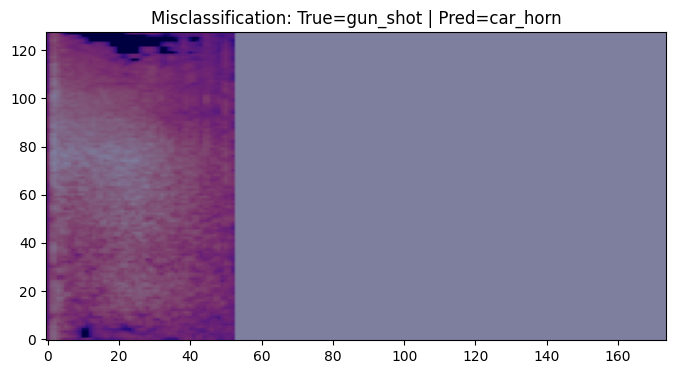

The model confused gun_shot for car_horn.
Possibility: Environmental overlapping noise obscured characteristic features, or both classes share similar mid-frequency harmonic profiles in this instance.


In [14]:
misclassified_indices = np.where(y_pred != y_true)[0]
if len(misclassified_indices) > 0:
    wrong_idx = misclassified_indices[0]
    wrong_img = X_test[wrong_idx:wrong_idx+1]
    
    t_class = class_map[y_true[wrong_idx]]
    p_class = class_map[y_pred[wrong_idx]]
    
    hm = make_gradcam_heatmap(wrong_img, model)
    hm_resized = cv2.resize(hm, (wrong_img.shape[2], wrong_img.shape[1]))
    
    plt.figure(figsize=(8, 4))
    plt.imshow(wrong_img[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
    plt.imshow(hm_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
    plt.title(f'Misclassification: True={t_class} | Pred={p_class}')
    plt.show()
    
    print(f"The model confused {t_class} for {p_class}.")
    print("Possibility: Environmental overlapping noise obscured characteristic features, or both classes share similar mid-frequency harmonic profiles in this instance.")



## 14. Noise Robustness Experiment
To test the resilience of the ESC model, we add artificial Gaussian noise and re-evaluate.



Original Accuracy: 44.67%
Accuracy with added noise: 52.33%
Accuracy Drop: -7.67%


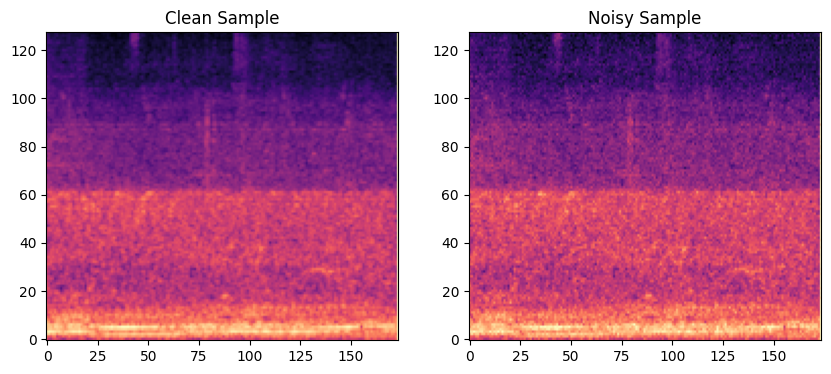

Using layer: conv2d_2 for Grad-CAM


D:\Deep Learning and QML Kernel\dl-kernel\my_dl_venv\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 174, 1))
  warnings.warn(msg)


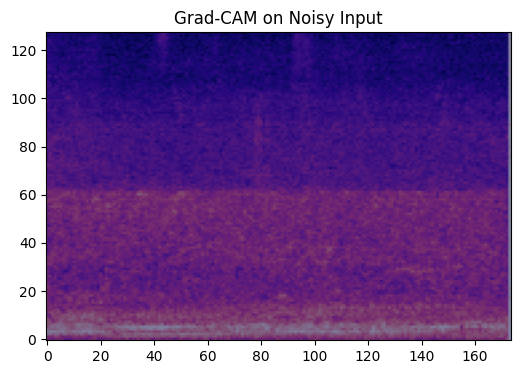

Notice how the heatmap's focus degrades or scatters due to the introduced noise.


In [15]:
# Generate noisy test set
noise_factor = 2.5 # high noise factor for demonstration
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
X_test_noisy = np.clip(X_test_noisy, np.min(X_test), np.max(X_test))

# Re-evaluate
noisy_score = model.evaluate(X_test_noisy, y_test, verbose=0)
print(f"Original Accuracy: {score[1]*100:.2f}%")
print(f"Accuracy with added noise: {noisy_score[1]*100:.2f}%")
print(f"Accuracy Drop: {(score[1] - noisy_score[1])*100:.2f}%")

# Visualize the effect on a single sample
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_array[0, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.title('Clean Sample')
plt.subplot(1, 2, 2)
plt.imshow(X_test_noisy[sample_idx, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.title('Noisy Sample')
plt.show()

# Visualize shifted Grad-CAM
hm_noisy = make_gradcam_heatmap(X_test_noisy[sample_idx:sample_idx+1], model)
hm_noisy_resized = cv2.resize(hm_noisy, (X_test_noisy.shape[2], X_test_noisy.shape[1]))

plt.figure(figsize=(6, 4))
plt.imshow(X_test_noisy[sample_idx, :, :, 0], aspect='auto', cmap='magma', origin='lower')
plt.imshow(hm_noisy_resized, aspect='auto', cmap='jet', alpha=0.5, origin='lower')
plt.title('Grad-CAM on Noisy Input')
plt.show()
print("Notice how the heatmap's focus degrades or scatters due to the introduced noise.")

